# Exploratory Data Analysis - Office Building AHU Dataset

**Source**: Wang, S. (2025). *Real operational labeled data of air handling
units from office, auditorium, and hospital buildings*. Scientific Data.
[Figshare DOI: 10.6084/m9.figshare.27147678.v3](https://doi.org/10.6084/m9.figshare.27147678.v3)

**Scope**: office building subset (`office_scientific_data.csv`) — 20 AHUs,
18 sensor variables, hourly readings from Dec 1, 2023 to Nov 30, 2024.

**Goal**: understand the dataset's structure, class balance, missing-data
patterns, and sensor behavior in order to inform downstream modeling
decisions (feature handling, class imbalance strategy, split design).

In [1]:
# Core libraries for data loading and visualization.
# seaborn is used on top of matplotlib for cleaner statistical plots
# (distributions, boxplots) with less boilerplate.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/office_scientific_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (175532, 21)


,AHU name,Time,Set point temperature,Return temperature,Supply air temperature,Supply fan,Valve position,Heating supply temperature1,Heating supply temperature2,Total heating pump,...,Heating pump 2,Heating pump 3,Cooling supply temperature 1,Cooling supply temperature 2,Total cooling pump,cooling pump 1,cooling pump 2,cooling pump 3,cooling pump 4,labeling
0,AHU-101,2024-06-01 00,22,21.87,21.83,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,15.23,14.16,0.0,0.0,0.0,0.0,0.0,Normal condition
1,AHU-101,2024-06-01 01,22,21.95,21.93,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,15.45,14.35,0.0,0.0,0.0,0.0,0.0,Normal condition
2,AHU-101,2024-06-01 02,22,22.01,22.03,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,15.68,14.54,0.0,0.0,0.0,0.0,0.0,Normal condition
3,AHU-101,2024-06-01 03,22,21.95,21.97,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,15.91,14.74,0.0,0.0,0.0,0.0,0.0,Normal condition
4,AHU-101,2024-06-01 04,22,21.89,21.91,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,16.12,14.93,0.0,0.0,0.0,0.0,0.0,Normal condition


## 1. Dataset overview

Basic structure: number of AHUs, sensor variables, and the time span
covered, confirmed against the paper's stated specifications (20 AHUs,
18 sensor variables, Dec 1 2023 – Nov 30 2024).

In [2]:
# Sanity-check the dataset's basic shape against the paper's stated specs
# before any deeper analysis.
print(f"Number of AHUs: {df['AHU name'].nunique()}")
print(f"Time range: {df['Time'].min()} to {df['Time'].max()}")
print(f"Total columns: {df.shape[1]}")

df.info()

Number of AHUs: 20
Time range: 2023-12-01 00 to 2024-11-30 23
Total columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 175532 entries, 0 to 175531
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AHU name                      175532 non-null  str    
 1   Time                          175532 non-null  str    
 2   Set point temperature         175532 non-null  int64  
 3   Return temperature            175532 non-null  float64
 4   Supply air temperature        175532 non-null  float64
 5   Supply fan                    175532 non-null  float64
 6   Valve position                175532 non-null  float64
 7   Heating supply temperature1   102120 non-null  float64
 8   Heating supply temperature2   102120 non-null  float64
 9   Total heating pump            102120 non-null  float64
 10  Heating pump 1                102120 non-null  float64
 11  Heating pump 2                10212

## 2. Label distribution

The `labeling` column is our target variable for fault classification.
Understanding class balance here is essential - severe imbalance (rare
fault types vs. abundant normal readings) directly affects model choice,
evaluation metric choice, and whether resampling techniques (e.g. SMOTE)
are needed for underrepresented classes.

In [3]:
# Raw counts and percentage share of each operational condition / fault type.
label_counts = df["labeling"].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": label_counts, "pct_of_total": label_pct})
summary

,count,pct_of_total
labeling,,
Normal condition,119402,68.02
Supply fan fault,47983,27.34
Return air temperature fault,6999,3.99
Supply air temperature fault,1031,0.59
Valve position fault,117,0.07


Visualizing the same distribution makes the imbalance immediately clear -
a log scale on the count axis is used since "Normal condition" is orders
of magnitude larger than the rarest fault classes, which would otherwise
be invisible on a linear scale.

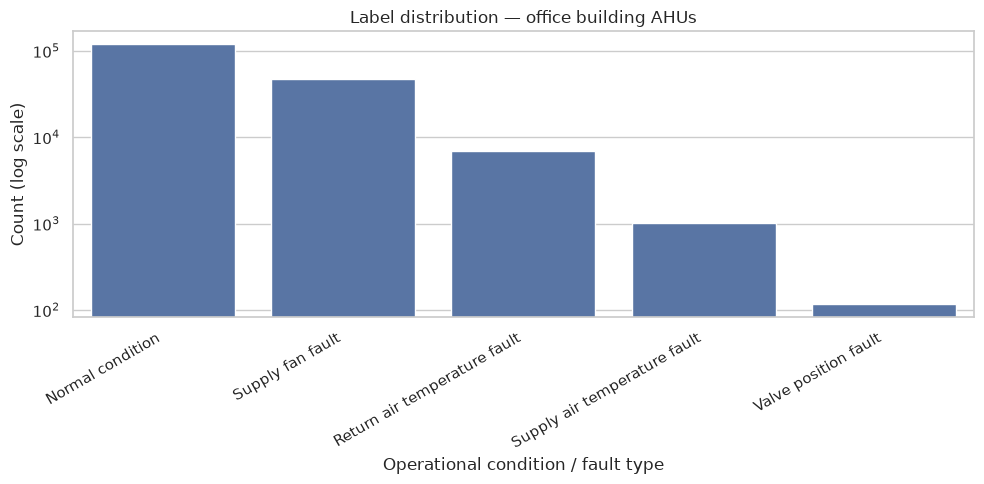

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_xlabel("Operational condition / fault type")
ax.set_title("Label distribution — office building AHUs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Observations

- Five classes are present: **Normal condition** (68.0%), **Supply fan
  fault** (27.3%), **Return air temperature fault** (4.0%), **Supply air
  temperature fault** (0.59%), and **Valve position fault** (0.07%, 117 rows).
- **Cooling pump fault** and **heating pump fault** - both defined in the
  annotation guidelines - do not occur at all in this building's dataset,
  consistent with stable pump operation over the collection period.
- The severe imbalance, particularly for Supply air temperature fault and
  Valve position fault, has two direct implications:
  1. **Evaluation metric**: overall accuracy would be misleading (a model
     predicting "Normal" for everything would score ~68% accuracy while
     being useless). Per-class precision/recall/F1, and macro-averaged F1,
     are the metrics that matter here.
  2. **Split design**: Valve position fault has too few samples (117) to
     reliably stratify into a 60/20/20 train/val/test split - a test set
     of ~23 rows is not enough to trust a reported metric. This will be
     addressed explicitly at the modeling stage (e.g. excluding it from
     stratified evaluation, or applying SMOTE to oversample it).

## 3. Missing data patterns

`df.info()` showed heating-related sensors are non-null for 102,120 rows
and cooling-related sensors for 73,412 rows - summing exactly to the total
row count (175,532), suggesting every reading belongs to exactly one mode
(heating or cooling), never both. This is verified explicitly below, since
it determines whether these nulls are **structural** (the sensor genuinely
does not apply, e.g. a heating pump reading when the AHU is cooling) rather
than data quality issues - a distinction that directly decides whether
imputation is appropriate.

In [5]:
heating_cols = ["Heating supply temperature1", "Heating supply temperature2",
                "Total heating pump", "Heating pump 1", "Heating pump 2", "Heating pump 3"]
cooling_cols = ["Cooling supply temperature 1", "Cooling supply temperature 2",
                "Total cooling pump", "cooling pump 1", "cooling pump 2",
                "cooling pump 3", "cooling pump 4"]

heating_null = df[heating_cols].isnull().all(axis=1)
cooling_null = df[cooling_cols].isnull().all(axis=1)

both_null = (heating_null & cooling_null).sum()
both_present = (~heating_null & ~cooling_null).sum()
heating_only = (~heating_null & cooling_null).sum()
cooling_only = (heating_null & ~cooling_null).sum()

print(f"Both heating and cooling null:      {both_null}")
print(f"Both heating and cooling present:   {both_present}")
print(f"Heating present, cooling null:      {heating_only}")
print(f"Cooling present, heating null:      {cooling_only}")

Both heating and cooling null:      0
Both heating and cooling present:   0
Heating present, cooling null:      102120
Cooling present, heating null:      73412


### Conclusion — missing data

Confirmed: every row has sensor readings for exactly one mode (heating or
cooling), never both and never neither. This is **structural absence**, not
missing/corrupted data - when an AHU is in cooling mode, its heating
actuators are inactive and simply have nothing to report, and vice versa.

**Decision**: these nulls will **not be imputed**. Filling them with 0, a
mean, or any other placeholder would misrepresent an inactive system as an
active one reading zero - a factually incorrect and potentially misleading
input for the model. The production pipeline (`src/data/load_sensor_data.py`)
preserves these as true `NULL` values in Postgres, and the model training
step will handle them appropriately 

## 4. Sensor value distributions by condition

Checking whether key sensors (supply air temperature, return temperature,
valve position) show visible separation between Normal and fault
conditions - this is a sanity check on the labeling itself, and early
signal on which features are likely to matter most for classification.

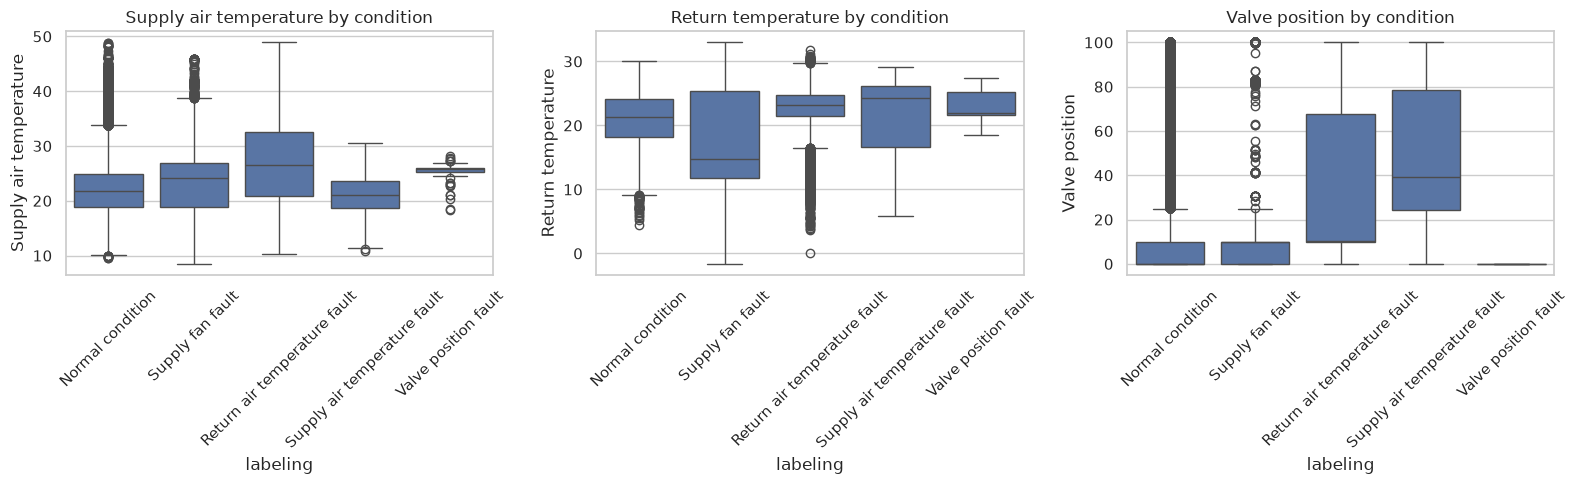

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="labeling", y="Supply air temperature", ax=axes[0])
axes[0].set_title("Supply air temperature by condition")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="labeling", y="Return temperature", ax=axes[1])
axes[1].set_title("Return temperature by condition")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="labeling", y="Valve position", ax=axes[2])
axes[2].set_title("Valve position by condition")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Median values across all four core room-side sensors, plus set point
# temperature for reference (the target the system is trying to hit).
core_sensors = ["Set point temperature", "Supply air temperature",
                 "Return temperature", "Supply fan", "Valve position"]

summary_stats = df.groupby("labeling")[core_sensors].median()
summary_stats

,Set point temperature,Supply air temperature,Return temperature,Supply fan,Valve position
labeling,,,,,
Normal condition,22.0,21.86,21.28,0.0,0.00
Return air temperature fault,19.0,26.51,23.18,1.0,10.31
Supply air temperature fault,22.0,21.06,24.24,0.5,39.27
Supply fan fault,22.0,24.07,14.75,0.0,10.00
Valve position fault,24.0,25.79,21.88,1.0,0.00


### Observations

Comparing each fault type against Normal condition as the baseline:

- **Supply fan fault**: return temperature is 14.75°C, over 6 degrees colder
  than every other condition. Set point (22.0°C) is the same as Normal's,
  so there's a large gap between target and actual room temperature. Supply
  fan reading is 0.0, same as Normal. The raw fan value alone looks fine.
  The fault only shows up once you notice the fan is idle despite a gap
  that should be triggering it to run. This matches Table 7's definition:
  not a broken fan, but a fan not responding to demand.
- **Supply air temperature fault**: valve position is 39.27%, by far the
  highest in the table (every other condition is 10% or below). Supply air
  temperature itself (21.06°C) is close to Normal's (21.86°C), so the air
  is actually fine. The system is working hard (high valve position) to
  correct a reading that was never actually wrong, since the fault is in
  the sensor, not the air.
- **Set point** ranges from 19.0°C to 24.0°C across conditions. This
  reflects different rooms having different comfort targets configured by
  occupants, not the fault itself. Worth keeping in mind so a configuration
  difference isn't mistaken for a fault signal.

Two implications for modeling:

- Accuracy alone won't tell us if a model is doing well, since some faults
  (like Supply fan fault) reveal themselves through the relationship
  between two sensors, not either sensor's raw value.
- A model that can learn from combinations of features together, like a
  gradient-boosted tree model, fits this better than one that judges each
  sensor independently.

## 5. Fault patterns over time and by AHU

Checking whether faults are spread evenly across AHUs and months, or
concentrated in specific units or periods. This tells us two things: which
AHUs are less reliable, and whether there is a fault-dense stretch worth
using later for the replay simulation demo.

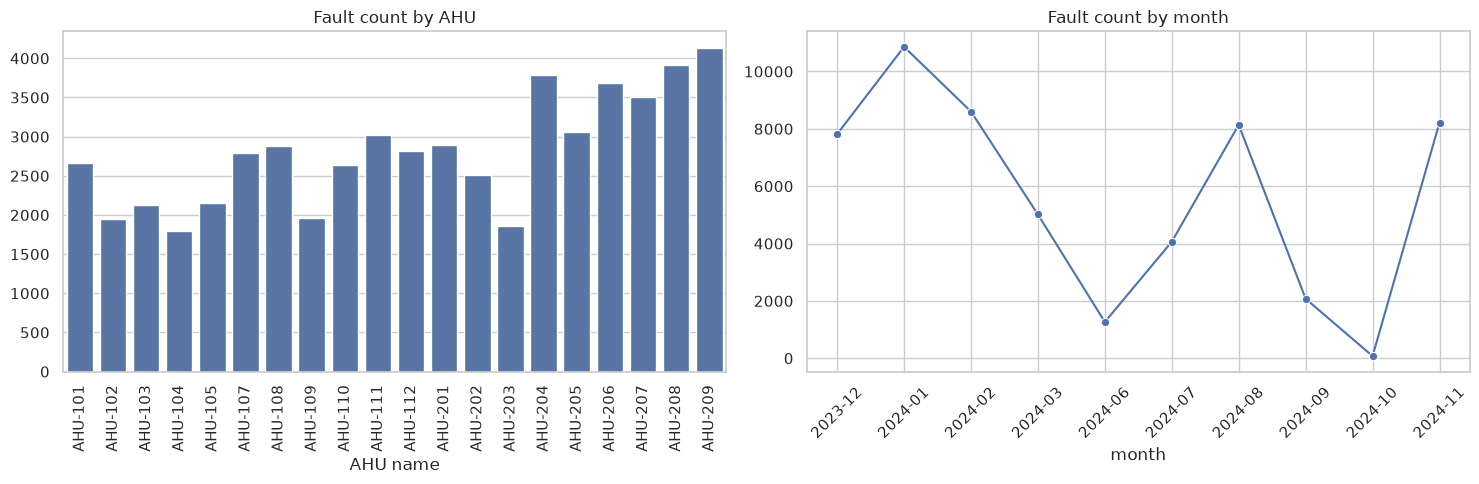

In [8]:
# Fault-only view (exclude Normal condition) to focus on where faults occur.
faults = df[df["labeling"] != "Normal condition"].copy()
faults["Time"] = pd.to_datetime(faults["Time"], format="%Y-%m-%d %H")
faults["month"] = faults["Time"].dt.to_period("M")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fault_by_ahu = faults["AHU name"].value_counts().sort_index()
sns.barplot(x=fault_by_ahu.index, y=fault_by_ahu.values, ax=axes[0])
axes[0].set_title("Fault count by AHU")
axes[0].tick_params(axis="x", rotation=90)

fault_by_month = faults.groupby("month").size()
sns.lineplot(x=fault_by_month.index.astype(str), y=fault_by_month.values, ax=axes[1], marker="o")
axes[1].set_title("Fault count by month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [9]:
print(fault_by_ahu)
print()
print(fault_by_month)

AHU name
AHU-101    2662
AHU-102    1945
AHU-103    2121
AHU-104    1791
AHU-105    2150
AHU-107    2793
AHU-108    2878
AHU-109    1959
AHU-110    2637
AHU-111    3016
AHU-112    2818
AHU-201    2888
AHU-202    2507
AHU-203    1860
AHU-204    3790
AHU-205    3063
AHU-206    3691
AHU-207    3509
AHU-208    3914
AHU-209    4138
Name: count, dtype: int64

month
2023-12     7816
2024-01    10860
2024-02     8602
2024-03     5013
2024-06     1266
2024-07     4064
2024-08     8140
2024-09     2075
2024-10       75
2024-11     8219
Freq: M, dtype: int64


In [10]:
# Check if April and May are missing entirely, or just have zero faults
all_months = pd.to_datetime(df["Time"], format="%Y-%m-%d %H").dt.to_period("M")
print(all_months.value_counts().sort_index())

Time
2023-12    14880
2024-01    14880
2024-02    13920
2024-03    14880
2024-04    14320
2024-05    14840
2024-06    14400
2024-07    14880
2024-08    14880
2024-09    14400
2024-10    14852
2024-11    14400
Freq: M, Name: count, dtype: int64


### Observations

**By AHU**: fault counts range from 1,791 (AHU-104) to 4,138 (AHU-209),
roughly a 2.3x spread. This is meaningful variation but not extreme, and
no single AHU dominates or is fault-free. This suggests fault type is a
better predictor than AHU identity alone, though AHU-209, AHU-208 and
AHU-204 (all above 3,700) may be worth flagging as comparatively less
reliable units in the final writeup.

**By month**: fault counts swing widely, from 10,860 in January 2024 down
to 75 in October 2024. Before drawing conclusions, we checked whether
April and May (the two lowest points on the chart) were actually missing
data or genuinely fault-free. Row counts for those months (14,320 and
14,840) are close to every other month's total, confirming the data itself
is complete. The dip is a real pattern in the building's operation, not a
gap in collection.

A plausible explanation is seasonal load. Winter months (December through
February) show the highest fault counts, which lines up with heating
systems working harder and having more opportunities to fail. Faults drop
through spring, bottom out in October, and rise again into November. This
is consistent with HVAC systems experiencing more stress during heating
season, though we are not treating this as confirmed without seasonal
sensor data (like outdoor temperature) to test the hypothesis directly.

**Implication for modeling**: month or season could be a useful engineered
feature if we want the model to account for this pattern. It also gives us
a natural choice for the replay simulation demo later. January 2024 is the
most fault-dense month and would make for a livelier demo window than a
quiet month like October.

## 6. Feature correlation

Checking for redundant sensors before modeling. Two sensors that are
almost perfectly correlated carry the same information, and keeping both
adds noise without adding signal.

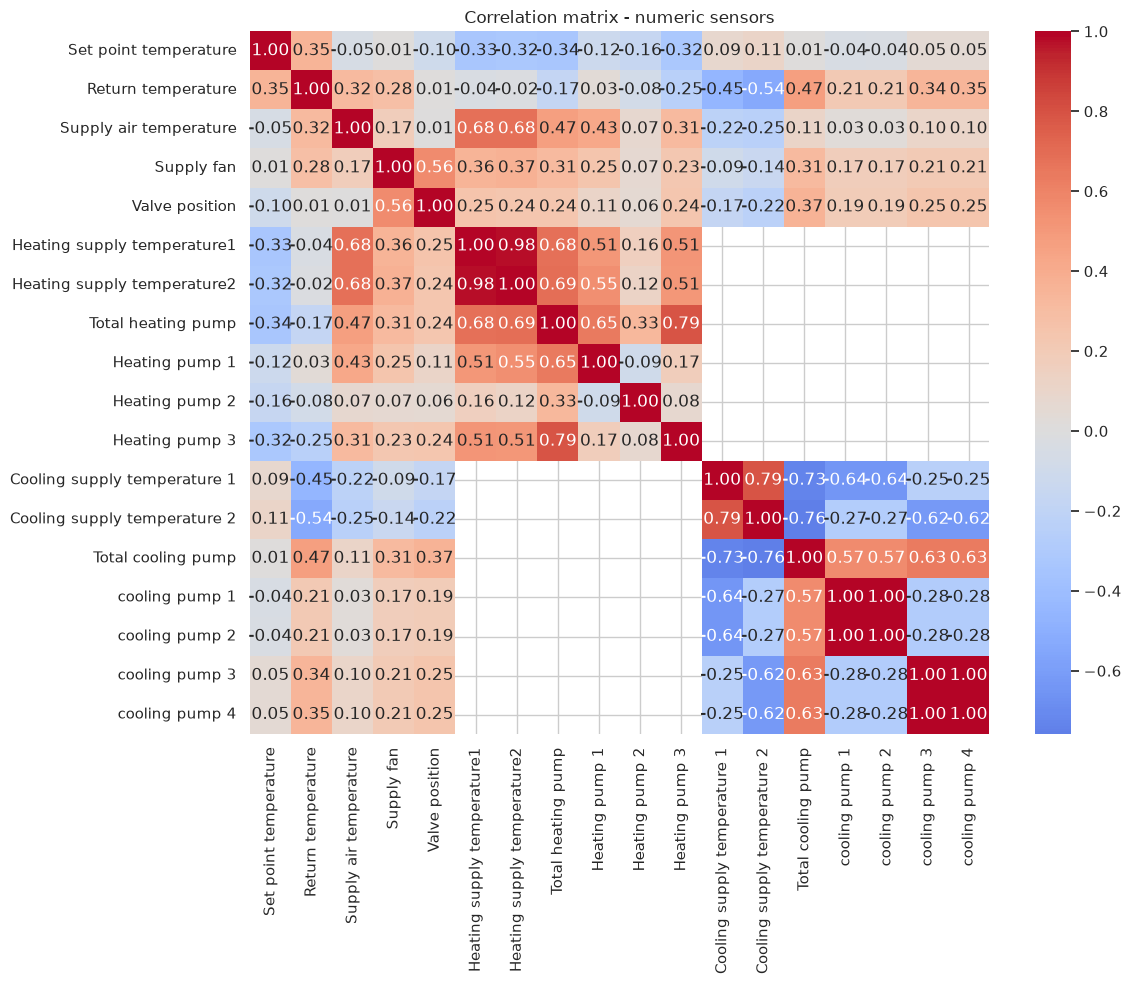

In [11]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation matrix - numeric sensors")
plt.tight_layout()
plt.show()

## 7. Range and outlier check

Comparing actual value ranges against Table 7's guideline ranges for
Normal condition, to catch any values that look physically implausible
(sensor errors, unit mismatches) rather than genuine fault behavior.

In [12]:
range_check = df[["Set point temperature", "Supply air temperature",
                   "Return temperature", "Supply fan", "Valve position"]].describe()
range_check

,Set point temperature,Supply air temperature,Return temperature,Supply fan,Valve position
count,175532.000000,175532.000000,175532.000000,175532.000000,175532.000000
mean,21.939196,22.627438,19.961463,0.178484,10.156202
std,2.876752,5.165246,5.206168,0.371887,19.114677
min,10.000000,8.490000,-1.630000,0.000000,0.000000
25%,19.000000,18.957500,16.300000,0.000000,0.000000
50%,22.000000,22.490000,20.390000,0.000000,9.740000
75%,24.000000,25.630000,24.290000,0.000000,10.000000
max,40.000000,48.900000,32.970000,1.000000,100.000000


In [13]:
# Supply fan's range (0 to 1) doesn't match a 0-100% speed reading.
# Confirming whether it's actually a binary on/off status instead.
print(df["Supply fan"].unique())
print(df["Supply fan"].value_counts())

[0.   0.5  1.   0.75 0.2  0.25 0.67 0.6  0.8  0.4  0.33 0.43 0.83 0.17
 0.29 0.56 0.38 0.45 0.71 0.63]
Supply fan
0.00    140945
1.00     27954
0.50      3132
0.75      1371
0.25      1227
0.60       322
0.40       221
0.80       137
0.20        95
0.67        46
0.17        29
0.83        20
0.33        13
0.29        10
0.43         3
0.56         2
0.38         2
0.45         1
0.71         1
0.63         1
Name: count, dtype: int64


In [14]:
# Check whether extreme readings are tied to specific fault types
# (expected) or scattered across Normal condition too (would suggest
# genuine data quality issues).
print(df[df["Return temperature"] < 0]["labeling"].value_counts())
print()
print(df[df["Supply air temperature"] > 35]["labeling"].value_counts())

labeling
Supply fan fault    16
Name: count, dtype: int64

labeling
Normal condition                2440
Return air temperature fault    1349
Supply fan fault                 544
Name: count, dtype: int64


## 8. Fault episode lengths

Faults appear as runs of consecutive hourly rows for one AHU. Measuring how
long these runs last, per fault type, shows how persistent each fault is and
how many are one-hour blips. This informs how the detection pipeline decides
when a flagged hour becomes a tracked fault.

In [15]:
# An episode is a run of consecutive hourly rows with the same label on one AHU.
eps = df[["AHU name", "Time", "labeling"]].copy()
eps["Time"] = pd.to_datetime(eps["Time"], format="%Y-%m-%d %H")
eps = eps.sort_values(["AHU name", "Time"]).reset_index(drop=True)

# A new episode starts when the AHU, the label, or the hourly spacing changes.
gap = eps.groupby("AHU name")["Time"].diff() != pd.Timedelta(hours=1)
label_change = eps["labeling"] != eps.groupby("AHU name")["labeling"].shift()
eps["episode_id"] = (gap | label_change).cumsum()

episodes = (
    eps[eps["labeling"] != "Normal condition"]
    .groupby(["episode_id", "AHU name", "labeling"])
    .size()
    .rename("hours")
    .reset_index()
)

summary = episodes.groupby("labeling")["hours"].agg(
    episodes="size",
    median_hours="median",
    longest_hours="max",
    pct_one_hour=lambda h: (h == 1).mean() * 100,
    pct_two_hours_or_less=lambda h: (h <= 2).mean() * 100,
)
summary.round(1)

,episodes,median_hours,longest_hours,pct_one_hour,pct_two_hours_or_less
labeling,,,,,
Return air temperature fault,1793,1.0,85,50.9,63.0
Supply air temperature fault,681,1.0,45,90.6,94.1
Supply fan fault,3168,9.0,768,16.7,24.1
Valve position fault,46,1.0,10,65.2,73.9


### Observations

- Supply fan fault is persistent, with a median of 9 hours, a longest run of 768 hours (about 32 days), and only 17% of episodes lasting a single hour.
- The other three fault types have a median of 1 hour. Single-hour episodes make up 91% of Supply air temperature fault, 65% of Valve position fault, and 51% of Return air temperature fault.
- Episodes were built from the true labels. A model's own flags will be more fragmented, so the rule for when a flagged hour becomes a tracked fault is set later, against model output.

## 9. Class counts by month

Monthly row counts per class show when each fault type occurs. This
informs how the data can be divided chronologically into training,
validation, and test periods while keeping every class represented.

In [16]:
by_month = (
    df.assign(month=pd.to_datetime(df["Time"], format="%Y-%m-%d %H").dt.to_period("M"))
      .groupby(["month", "labeling"]).size().unstack(fill_value=0)
)
by_month

labeling,Normal condition,Return air temperature fault,Supply air temperature fault,Supply fan fault,Valve position fault
month,,,,,
2023-12,7064,2235,196,5385,0
2024-01,4020,1490,70,9300,0
2024-02,5318,895,72,7635,0
2024-03,9867,378,87,4548,0
2024-04,14320,0,0,0,0
2024-05,14840,0,0,0,0
2024-06,13134,177,24,1029,36
2024-07,10816,722,193,3141,8
2024-08,6740,568,274,7244,54


### Observations

- Valve position fault occurs only from June to October, with 36, 8, 54, 15, and 4 rows. No other month has any.
- April and May contain no faults of any kind, although both months have complete rows. The data cannot show whether the building was fault-free or whether those months were labeled Normal by default.
- Supply fan fault is heaviest from December to February and again in August and November. All fault types nearly disappear in October.

## 10. March fault timing

Fault counts per day and the longest episodes in March, used to choose where
to cut the month into a training half and a test half.

In [17]:
march = df.assign(t=pd.to_datetime(df["Time"], format="%Y-%m-%d %H"))
march = march[march["t"].dt.to_period("M") == "2024-03"]
daily = march.groupby([march["t"].dt.day.rename("day"), "labeling"]).size().unstack(fill_value=0)
print(daily)

ep_span = (
    eps[eps["labeling"] != "Normal condition"]
    .groupby(["episode_id", "AHU name", "labeling"])["Time"]
    .agg(start="min", end="max", hours="size")
    .reset_index()
)
in_march = ep_span[(ep_span["end"] >= "2024-03-01") & (ep_span["start"] < "2024-04-01")]
in_march.sort_values("hours", ascending=False).head(10)

labeling  Normal condition  Return air temperature fault  \
day                                                        
1                      131                             0   
2                       90                             0   
3                      290                             0   
4                      205                            16   
5                      341                            58   
6                      300                            22   
7                      175                            46   
8                      140                            19   
9                      259                             0   
10                     267                             0   
11                     192                            18   
12                     268                            21   
13                     193                            31   
14                     379                            10   
15                     309              

,episode_id,AHU name,labeling,start,end,hours
5428,8977,AHU-208,Supply fan fault,2024-03-07 00:00:00,2024-03-09 08:00:00,57
5293,8712,AHU-207,Supply fan fault,2024-03-07 00:00:00,2024-03-09 08:00:00,57
5153,8440,AHU-206,Supply fan fault,2024-03-07 00:00:00,2024-03-09 08:00:00,57
5576,9267,AHU-209,Supply fan fault,2024-03-07 00:00:00,2024-03-09 08:00:00,57
5287,8700,AHU-207,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42
5422,8965,AHU-208,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42
5147,8428,AHU-206,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42
512,781,AHU-102,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42
4899,8007,AHU-205,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42
782,1218,AHU-103,Supply fan fault,2024-02-29 21:00:00,2024-03-02 14:00:00,42


In [18]:
wk = march[march["t"].dt.dayofweek >= 5]
wk.groupby([wk["t"].dt.day.rename("day"), "labeling"])["Supply fan"].mean().unstack().round(2)

labeling,Normal condition,Supply fan fault
day,,
2,0.00,0.0
3,0.00,0.0
9,0.00,0.0
10,0.00,0.0
16,0.06,NaN
17,0.00,NaN
23,0.00,NaN
24,0.00,NaN
30,0.00,NaN


In [19]:
wk = df.assign(t=pd.to_datetime(df["Time"], format="%Y-%m-%d %H"))
wk = wk[(wk["t"].dt.dayofweek >= 5) & (wk["Supply fan"] == 0)]
(
    wk.groupby([wk["t"].dt.to_period("M"), "labeling"]).size()
      .unstack(fill_value=0)
)

labeling,Normal condition,Supply fan fault
t,,
2023-12,1448,2056
2024-01,575,2929
2024-02,1260,2580
2024-03,3750,1014
2024-04,3840,0
2024-05,3840,0
2024-06,4445,259
2024-07,2792,933
2024-08,1279,2644


### Observations

- Fault rows appear on every weekday and on the first two weekends (March 2 to 3 and 9 to 10, fan faults only). From March 16 on, weekend days contain no fault rows.
- The longest episode touching March is 57 hours. Several AHUs share identical start and end times, so these are building-wide events.
- No fault rows exist on March 16 and 17, so cutting the month there splits no episode.

## 11. Fan schedule and weekend labeling

Supply fan on-time by hour of day, split into weekdays and weekends, shows
the operating schedule and which clock the timestamps use. Weekend hours with
the fan off are labeled Normal in some months and Supply fan fault in others,
so those rows are compared against the gap between return temperature and set
point.

In [20]:
wk = df.assign(t=pd.to_datetime(df["Time"], format="%Y-%m-%d %H"))
wk = wk[(wk["t"].dt.dayofweek >= 5) & (wk["Supply fan"] == 0)].copy()
wk["gap_C"] = (wk["Return temperature"] - wk["Set point temperature"]).abs()
wk.groupby([wk["t"].dt.to_period("M"), "labeling"])["gap_C"].median().unstack().round(1)

labeling,Normal condition,Supply fan fault
t,,
2023-12,2.0,8.9
2024-01,1.9,7.5
2024-02,5.7,7.4
2024-03,4.1,7.3
2024-04,3.1,NaN
2024-05,6.6,NaN
2024-06,2.2,3.6
2024-07,3.4,4.6
2024-08,2.3,4.8


In [21]:
t = pd.to_datetime(df["Time"], format="%Y-%m-%d %H")
prof = (
    df.assign(hour=t.dt.hour, weekend=t.dt.dayofweek >= 5)
      .groupby(["weekend", "hour"])["Supply fan"].mean()
      .unstack(0).round(2)
)
prof.columns = ["weekday", "weekend"]
prof

,weekday,weekend
hour,,
0,0.04,0.05
1,0.04,0.05
2,0.04,0.05
3,0.04,0.05
4,0.04,0.05
5,0.05,0.05
6,0.07,0.06
7,0.18,0.06
8,0.39,0.07


### Observations

- Weekday fan on-fraction is about 0.4 to 0.45 from 08:00 to 17:00 and falls off after 19:00. On weekends it stays between 0.05 and 0.09. This is an office schedule on a local clock.
- Weekend hours with the fan off are labeled Supply fan fault in some months and Normal in others. The fault share ranges from 0% (April and May) to 84% (January), and these rows make up about 15,800 of the 47,983 Supply fan fault rows.
- Fault-labeled rows have the larger gap between return temperature and set point in all ten months that have both labels. However, Normal-labeled rows in May (median gap 6.6°C) exceed fault-labeled rows in June through September (3.6 to 4.8°C), so the labeling is not consistent across months.

## 12. Outdoor temperature

Hourly 2 m air temperature from the Open-Meteo historical archive (ERA5
reanalysis, roughly 25 km grid, CC BY 4.0), fetched for approximately
37.43°N, 126.99°E with timestamps requested in GMT. This is a modeled
estimate for the area, not a reading from the building's own sensor.

In [22]:
import requests

LAT, LON = 37.43, 126.99  # approximate location of Gwacheon

def fetch_weather(start, end):
    r = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": LAT, "longitude": LON,
            "start_date": start, "end_date": end,
            "hourly": "temperature_2m", "timezone": "GMT",
        },
        timeout=60,
    )
    r.raise_for_status()
    h = r.json()["hourly"]
    return pd.DataFrame({"time_utc": pd.to_datetime(h["time"]),
                         "outdoor_temp": h["temperature_2m"]})

# One request per month. Starting in November 2023 leaves a margin for timezone shifts.
starts = pd.date_range("2023-11-01", "2024-11-01", freq="MS")
weather = pd.concat(
    fetch_weather(s.strftime("%Y-%m-%d"),
                  (s + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d"))
    for s in starts
).drop_duplicates("time_utc").reset_index(drop=True)

weather.to_csv("../data/processed/outdoor_temp_utc.csv", index=False)
print(weather.shape, weather["outdoor_temp"].isna().sum(), "missing")
weather.head()

(9504, 2) 0 missing


,time_utc,outdoor_temp
0,2023-11-01 00:00:00,14.5
1,2023-11-01 01:00:00,16.3
2,2023-11-01 02:00:00,17.6
3,2023-11-01 03:00:00,19.7
4,2023-11-01 04:00:00,21.2


In [23]:
w = weather.copy()
w["t_local"] = w["time_utc"] + pd.Timedelta(hours=9)  # Korea Standard Time is UTC+9
w["hour"] = w["t_local"].dt.hour
w.groupby("hour")["outdoor_temp"].mean().round(1)

hour
0     10.3
1     10.0
2      9.8
3      9.5
4      9.3
5      9.1
6      9.0
7      9.4
8     10.4
9     12.0
10    13.3
11    14.6
12    15.6
13    16.3
14    16.7
15    16.7
16    16.3
17    15.4
18    14.0
19    12.9
20    12.0
21    11.3
22    11.1
23    10.7
Name: outdoor_temp, dtype: float64

In [24]:
d = df.assign(t_local=pd.to_datetime(df["Time"], format="%Y-%m-%d %H"))
d = d.merge(w[["t_local", "outdoor_temp"]], on="t_local", how="left")
print(d["outdoor_temp"].isna().sum(), "rows without weather")

wk = d[(d["t_local"].dt.dayofweek >= 5) & (d["Supply fan"] == 0)].copy()
wk["band"] = pd.cut(wk["outdoor_temp"], [-30, 0, 5, 10, 15, 20, 25, 40])
tab = wk.groupby(["band", "labeling"], observed=True).size().unstack(fill_value=0)
tab["fault_share_%"] = (tab["Supply fan fault"] / tab.sum(axis=1) * 100).round(0)
tab

0 rows without weather


labeling,Normal condition,Supply fan fault,fault_share_%
band,,,
"(-30, 0]",1107,5322,83.0
"(0, 5]",2246,3981,64.0
"(5, 10]",3685,1150,24.0
"(10, 15]",5804,508,8.0
"(15, 20]",6971,522,7.0
"(20, 25]",7640,1070,12.0
"(25, 40]",3820,3245,46.0


In [25]:
wk["month"] = wk["t_local"].dt.to_period("M")
sel = wk[wk["band"].isin(wk["band"].cat.categories[[1, 2, 3]])]  # 0-5, 5-10, 10-15 C

share = (
    sel.groupby(["month", "band"], observed=True)["labeling"]
       .apply(lambda s: (s == "Supply fan fault").mean() * 100)
       .unstack().round(0)
)
counts = sel.groupby(["month", "band"], observed=True).size().unstack()

display(share)
display(counts)

band,"(0, 5]","(5, 10]","(10, 15]"
month,,,
2023-12,65.0,15.0,0.0
2024-01,89.0,NaN,NaN
2024-02,65.0,26.0,NaN
2024-03,23.0,0.0,0.0
2024-04,0.0,0.0,0.0
2024-05,NaN,0.0,0.0
2024-06,NaN,NaN,0.0
2024-10,NaN,0.0,1.0
2024-11,96.0,83.0,40.0


band,"(0, 5]","(5, 10]","(10, 15]"
month,,,
2023-12,858.0,492.0,360.0
2024-01,1446.0,NaN,NaN
2024-02,1560.0,720.0,NaN
2024-03,1460.0,1502.0,602.0
2024-04,80.0,760.0,1460.0
2024-05,NaN,100.0,880.0
2024-06,NaN,NaN,120.0
2024-10,NaN,186.0,1657.0
2024-11,823.0,1075.0,1233.0


### Observations

- The weather fetch returned 9,504 hourly values with none missing. After shifting UTC by 9 hours, outdoor temperature peaks at 14:00 to 15:00, and every building row matched a weather value.
- For weekend hours with the fan off, the fault-labeled share follows a U shape: 83% at 0°C or below, 64% from 0 to 5°C, 24% from 5 to 10°C, 7% to 8% from 10 to 20°C, 12% from 20 to 25°C, and 46% above 25°C.
- At the same temperature, the share still differs by month. In the 0 to 5°C band it is 0% in April, 23% in March, and 96% in November. Outdoor temperature explains part of the labeling and not all of it.
- The values are an area estimate on a roughly 25 km grid and not a reading from the building. Whether it helps as a model feature is tested later with month-grouped cross-validation.

## 13. What defines each fault in the data

Range of the fan and valve readings within each class, and whether each class
occurs in heating mode or cooling mode (heating mode means the heating sensor
group is filled in). This shows which readings a fault class actually changes,
which matters for reasoning about the effect of each fault.

In [26]:
ranges = df.groupby("labeling")[["Supply fan", "Valve position"]].agg(["min", "max"]).round(2)
display(ranges)

mode = df["Total heating pump"].notna().map({True: "heating mode", False: "cooling mode"})
display(pd.crosstab(df["labeling"], mode))

Supply fan      Valve position       
                                    min  max            min    max
labeling                                                          
Normal condition                   0.00  1.0           0.00  100.0
Return air temperature fault       0.17  1.0           0.00  100.0
Supply air temperature fault       0.20  1.0           0.16  100.0
Supply fan fault                   0.00  0.0           0.00  100.0
Valve position fault               0.20  1.0           0.00    0.0

Total heating pump,cooling mode,heating mode
labeling,,
Normal condition,57792,61610
Return air temperature fault,1710,5289
Supply air temperature fault,555,476
Supply fan fault,13238,34745
Valve position fault,117,0


### Observations

- Every Supply fan fault row has the fan at exactly 0. No other fault class ever has the fan fully off (lowest fan readings are 0.17 for Return air temperature fault and 0.20 for Supply air temperature fault and Valve position fault). Among the fault classes, the fan reading alone separates Supply fan fault from the rest. Against Normal it does not, because Normal rows often have the fan at 0 too.
- Every Valve position fault row has the valve at exactly 0 with the fan running, and all 117 rows occur in cooling mode (heating sensors empty). A closed valve is also common in Normal rows, so the fault only shows next to the fan, pump, and temperature readings.
- Mode here means which sensor group is filled in, which is not the same as the calendar season. Supply fan fault is 72% heating mode (34,745 of 47,983 rows), Return air temperature fault 76%, Normal 52%, and Supply air temperature fault 46%.
- Because the fan is off in every Supply fan fault row, a fan-power estimate does not apply to that fault. Energy effects have to be worked out per fault type.

## 14. Proposed evaluation split

Checking class counts under the planned evaluation design before it is
implemented. Whole blocks are held out as the test set: December (winter),
March 18 to 31 (spring), July (summer), and September (autumn). Rows within
24 hours of a test block are dropped from training so neighboring hours do not
sit on both sides of a boundary, and March 16 and 17 are dropped as an extra
gap between the March training half and test half. Everything else forms the
training pool, which month-grouped cross-validation later divides into folds.

In [27]:
t = pd.to_datetime(df["Time"], format="%Y-%m-%d %H")
day = pd.Timedelta(hours=24)

test_blocks = [
    ("2023-12-01 00:00", "2023-12-31 23:00"),
    ("2024-03-18 00:00", "2024-03-31 23:00"),
    ("2024-07-01 00:00", "2024-07-31 23:00"),
    ("2024-09-01 00:00", "2024-09-30 23:00"),
]
extra_gaps = [("2024-03-16 00:00", "2024-03-17 23:00")]

is_test = pd.Series(False, index=df.index)
is_gap = pd.Series(False, index=df.index)
for start, end in test_blocks:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    is_test |= (t >= s) & (t <= e)
    is_gap |= ((t >= s - day) & (t < s)) | ((t > e) & (t <= e + day))
for start, end in extra_gaps:
    is_gap |= (t >= pd.Timestamp(start)) & (t <= pd.Timestamp(end))
is_gap &= ~is_test

part = pd.Series("train pool", index=df.index)
part[is_gap] = "gap (dropped)"
part[is_test] = "test"

counts = pd.crosstab(df["labeling"], part)
counts["test_share_%"] = (counts["test"] / counts.sum(axis=1) * 100).round(0)
counts

col_0,gap (dropped),test,train pool,test_share_%
labeling,,,,
Normal condition,2939,35573,80890,30.0
Return air temperature fault,66,3324,3609,47.0
Supply air temperature fault,13,487,531,47.0
Supply fan fault,822,11473,35688,24.0
Valve position fault,0,23,94,20.0


### Observations

- The test blocks hold 50,880 rows (29% of the data). The training pool holds 120,812 rows, and 3,840 rows (2.2%) are dropped as gaps.
- All five classes appear in the test set and in the training pool. Valve position fault has 23 test rows (8 from July and 15 from September) and 94 in the training pool. No Valve position fault rows fall in the gaps, because the days next to the test blocks (June 30, August 1, August 31, October 1) contain none.
- The two sensor faults are concentrated in the test blocks (47% of rows each), because December alone holds 2,235 of the 6,999 Return air temperature fault rows and 196 of the 1,031 Supply air temperature fault rows. The training pool keeps 3,609 and 531 rows.
- Normal has 30% of its rows in test, Supply fan fault 24%, and Valve position fault 20%.
- Rows inside a block are not independent. Neighboring hours are near copies, and many AHUs share fault windows. The effective sample size is smaller than the row counts, most of all for the rare classes.
- The loader script will assign the split in the database. Month-grouped cross-validation later cuts folds inside the training pool.

## Summary

The analysis started from one question: can this dataset support a fault detection model? Each result raised the next question. The steps below follow that order, and the decisions at the end come from the whole chain.

### 1. Is the data complete and usable?

The first check covered what the file holds and whether anything is missing or repeated. It has 175,532 hourly rows for 20 AHUs from Dec 1 2023 to Nov 30 2024, with 18 sensor columns and a label. There are no duplicate rows or repeated timestamps. Across all units 148 hours (0.08%) are missing, for example six for AHU-101, and the column types match the database schema. Missing hours stay as gaps. This raised the question of what the labels look like.

### 2. How balanced are the classes?

Normal condition is 68.0% of rows and Supply fan fault 27.3%. Return air temperature fault is 4.0%, Supply air temperature fault 0.59%, and Valve position fault 0.07% (117 rows). Cooling pump fault and heating pump fault never occur in this building. A model that always predicts Normal would score about 68% accuracy, so per-class precision, recall, and F1 are the right measures, with macro F1 as the main number. Valve position fault is too thin to learn on its own. The overview also showed many empty cells in the heating and cooling columns, which raised the next question.

### 3. Are the empty cells missing data?

Heating sensors are filled in 102,120 rows and cooling sensors in 73,412 rows. Together that is all 175,532 rows, and no row has both groups or neither. An empty cell therefore means that equipment was inactive in that mode. Filling it with zero or an average would describe an inactive system as running at zero, so the cells stay empty. With the data understood, the question became whether the faults are easy to tell apart.

### 4. Can one sensor identify a fault?

Median readings and value ranges per class show that no single sensor separates all the classes. Valve position stands out for Supply air temperature fault (median 39.3%, against 10.3% or lower for every other class). Every Supply fan fault row has the fan at exactly 0, and no other fault class ever has the fan fully off. Normal rows often show 0 as well, and the fault's median return temperature is 14.8°C against 21.3°C for Normal. Every Valve position fault row has the valve at exactly 0 with the fan running, and all 117 rows are in cooling mode, yet a closed valve is also common in Normal rows. The fault definitions describe a reading that does not match demand, so the same reading can be normal or faulty depending on the rest of the row. Before trusting the columns as inputs, the next question was whether any of them duplicate each other or hold impossible values.

### 5. Are the sensors redundant, and are the values plausible?

Heating supply temperature 1 and 2 correlate at 0.98, and cooling pumps 1 and 2, and 3 and 4, correlate at 1.00. Return temperature below 0°C (lowest -1.63°C) occurs only in Supply fan fault rows. Supply air above 35°C appears in 4,333 rows, of which 2,440 are Normal, so it reflects normal heating operation. The supply fan value runs from 0 to 1 with fractions such as 0.5. The raw readings were logged every minute and averaged to hours, so the value is the share of the hour the fan was running and not a speed. No rows are removed as outliers. This raised the question of how faults are spread across units and time.

### 6. Where and when do faults occur?

Fault rows per AHU range from 1,791 (AHU-104) to 4,138 (AHU-209), about a 2.3x spread. By month, faults are highest from December to February, in August, and in November. They fall to 1,266 rows in June and 75 in October. April and May have no faults at all, although their rows are complete, and the data cannot show whether those months were fault-free or labeled Normal by default. Valve position fault occurs only from June to October. Faults are tied to the time of year, and one class cannot appear in every season. Since neighboring hours looked alike, the next question was how long a fault lasts.

### 7. How long do faults last?

Grouping consecutive hourly rows with the same label on the same AHU gives fault episodes.

| Fault | Episodes | Median hours | Longest | Last one hour |
|---|---|---|---|---|
| Supply fan fault | 3,168 | 9 | 768 | 17% |
| Return air temperature fault | 1,793 | 1 | 85 | 51% |
| Supply air temperature fault | 681 | 1 | 45 | 91% |
| Valve position fault | 46 | 1 | 10 | 65% |

Supply fan faults persist for hours to days, and sensor faults are mostly brief. Consecutive hours are near copies of each other. So a fault should be tracked as one episode that spans many readings, and evaluation cannot treat rows as independent. The longest fan fault runs, and a pattern in March, raised a question about the labels themselves.

### 8. What do the fan labels follow?

In March, weekend faults appear only on March 2 to 3 and 9 to 10, and none appear after March 16. On weekdays the fan on-fraction is about 0.4 to 0.45 from 08:00 to 17:00, and on weekends it stays between 0.05 and 0.09. That is an office schedule on a local clock. Weekend hours with the fan off are labeled Supply fan fault in some months and Normal in others, from 0% in April and May to 84% in January. These rows make up about 15,800 of the 47,983 Supply fan fault rows. Fault-labeled rows have the larger gap between return temperature and set point in all ten months that have both labels, so the labels lean toward demand. Normal-labeled rows in May (median gap 6.6°C) still exceed fault-labeled rows from June to November (3.6 to 5.8°C), so the labels are not applied consistently across months. The source paper states that experts annotated the data by hand, which makes variation in borderline hours plausible. If demand drives the labels, outdoor conditions should explain them, and that was the next question.

### 9. Does outdoor temperature explain the labels?

Hourly 2 m air temperature came from the Open-Meteo historical archive (ERA5 reanalysis, roughly a 25 km grid, CC BY 4.0). It was requested in UTC and shifted by 9 hours to local time. The fetch returned 9,504 hourly values with none missing, every building row matched one, and temperature peaks at 14:00 to 15:00 after the shift. For weekend fan-off hours, the fault-labeled share forms a U shape: 83% at 0°C or below, 64% from 0 to 5°C, 24% from 5 to 10°C, 7% to 8% from 10 to 20°C, 12% from 20 to 25°C, and 46% above 25°C. At the same temperature the share still differs by month. In the 0 to 5°C band it is 0% in April, 23% in March, and 96% in November. Outdoor temperature explains part of the labeling and a share of that is a calendar effect, since cold hours fall in winter. The values are an area estimate and not a reading from the building. What remained was how to evaluate a model on data like this.

### 10. How should the model be evaluated?

Neighboring hours are near copies, so a random split puts the neighbors of every test row in training and inflates scores. The data covers one year, so each season appears once. A strict cut by time would leave Valve position fault with more validation rows than training rows (54 against 44). The design is to hold out whole blocks, one per season: December, March 18 to 31, July, and September. March 1 to 15 stays in training, and March 16 and 17 are dropped as a gap. Rows within 24 hours of any other test block are dropped from training.

| Class | Training pool | Test | Dropped as gap |
|---|---|---|---|
| Normal condition | 80,890 | 35,573 | 2,939 |
| Return air temperature fault | 3,609 | 3,324 | 66 |
| Supply air temperature fault | 531 | 487 | 13 |
| Supply fan fault | 35,688 | 11,473 | 822 |
| Valve position fault | 94 | 23 | 0 |

Every class appears in the test set and in the training pool.

## What we learned

- The data is complete enough to use, and its empty cells carry meaning.
- The classes are heavily imbalanced, and one class has 117 rows in total.
- Faults show up in combinations of sensors and not in any single reading.
- Sensor faults are brief and fan faults are long, so a fault is a period of time.
- Faults follow the time of year, and the rarest class exists only from June to October.
- Fan-off weekend hours are labeled inconsistently across months, and outdoor temperature explains part of it.
- Rows in one time block are not independent, which drives how the model must be tested.

## Decisions

| Decision | Reason |
|---|---|
| Judge models by per-class precision, recall, and F1, with macro F1 as the main number | Normal is 68% of rows |
| Oversample Valve position fault with SMOTE inside training folds only | 117 rows in total, and held-out data stays real |
| Keep empty heating and cooling cells empty | They mark inactive equipment |
| Use models that learn combinations of sensors | No single sensor separates the faults |
| Keep every column | Redundant pairs are harmless for tree models, and feature importance shows their value later |
| Treat Supply fan as an on-time fraction and remove no outliers | It is an hourly average, and extreme values belong to specific fault classes |
| Track each fault as one episode, with the rule for when a flagged hour becomes a tracked fault set against model output | 91% of Supply air temperature fault episodes and 51% of Return air temperature fault episodes last one hour |
| Report Supply fan fault results for weekdays and weekends separately | Weekend fan-off labeling varies by month |
| Test outdoor temperature as an added feature, and keep it only if month-grouped cross-validation improves | It is an area estimate, and part of its signal is calendar |
| Use no month, day-of-year, or season feature | With one year each date occurs once, so a model could memorize when faults occur |
| Hold out the test blocks above, with the gap rules | Neighboring hours are near copies |
| Tune with month-grouped cross-validation on the training pool | It replaces a fixed validation set and uses every rare row |
| Retrain the final model on all twelve months after evaluation | Evaluation and the shipped model have different jobs |

## Limits

- One building and one year. The results say nothing about other buildings or other years.
- Rows inside a test block are not independent, and the rare classes have few test rows (23 for Valve position fault), so their scores are noisy and are reported with ranges.
- The labels come from expert-defined rules and, for weekend fan-off hours, were applied inconsistently across months, so scores measure agreement with those labels.

These findings feed the next step: comparing candidate classifiers under this evaluation design before building the production training pipeline.